Jahresertrag mit Wetter: 0.25 kWh
Jahresertrag ideal: 0.86 kWh


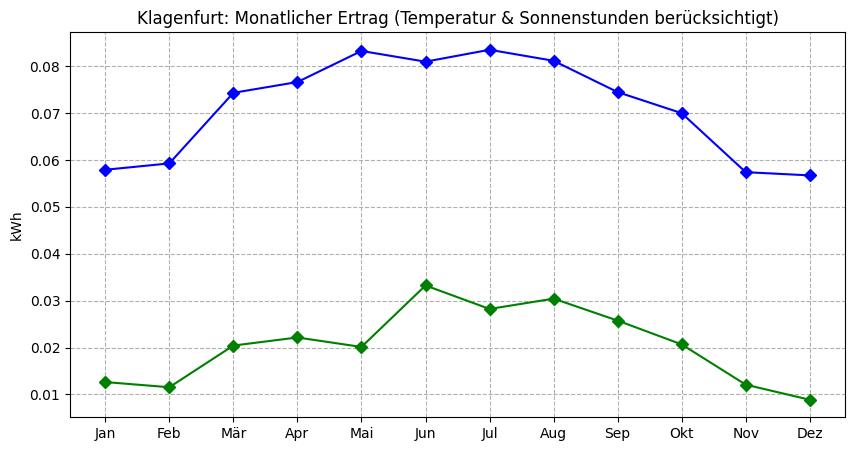

In [19]:
import math
import matplotlib.pyplot as plt
import pvlib
from pvlib import solarposition, irradiance, atmosphere

# --- 1. EINSTELLUNGEN ---
lat, lon = 46.6244, 14.3053  # Klagenfurt
tilt = 16.26   # Neigung Dach (5 Folien)
tilt2 = 90     # Neigung Fassade (2 Folien)
azimuth = 180  # Süden 180, West 270, Ost 90, Südost 135 Südwest 225
peak_power = 0.055  # kWp pro Folie

# Klagenfurt Statistiken
sun_hours_month = [1.5, 1.6, 2.5, 3, 2.7, 5.2, 4.3, 3.8, 3.8, 2.9, 1.8, 1.3] # Sonnenstunden/Tag durchschnitt
cloud_factor = [0.69, 0.78, 0.59, 0.57, 0.63, 0.4, 0.58, 0.49, 0.70, 0.8, 0.87, 0.98] 
max_daylight_hours_list = [9, 10.15, 11.90, 13.50, 14.9, 15.75, 15.5, 12.5, 12.5, 10.9, 9.5, 8.5] #durchschnitt
temp_max_month = [4.8, 5.8, 12.6, 17.5, 20, 29.7, 26.7, 22.3, 22.3, 14.7, 7.1, 2]      # Tageshöchstwert/Monat durchschnitt
temp_min_month = [-3.8, -1.5, 1.9, 6.1, 9, 15.6, 15.1, 12.5, 12.5, 4.8, -0.1, -0.7]     # Nachthöchstwert/Monat durchschnitt

# --- 2. SIMULATION ---
months = range(1, 13)
monthly_yield_kwh_i = []
monthly_yield_kwh_w = []
days_in_month_list = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

for month in months:
    total_energy_wh_w = 0  
    total_energy_wh_i = 0
    day = 15
    
    # 2.2 Gewichtungsfaktor: Wie viel der maximalen Sonne scheint wirklich?
    # Wir kombinieren Sonnenstunden und Cloud-Factor
    max_daylight_hours = max_daylight_hours_list[month-1]
    sun_ratio = sun_hours_month[month-1] / max_daylight_hours
    # Effektive Effizienz: Mischung aus direkter Sonne und diffuser Strahlung bei Bewölkung
    real_weather_factor = (sun_ratio * 1.0) + ((1 - sun_ratio) * (1 - cloud_factor[month-1]) * 0.2)

    for hour in range(24):
        time = f"2024-{month:02d}-{day:02d} {hour:02d}:00:00"
        solpos = solarposition.get_solarposition(time, lat, lon)
        elevation = solpos['elevation'].iloc[0]
        zenith = solpos['zenith'].iloc[0]
        
        if elevation > 0:
            # --- STÜNDLICHE TEMPERATUR SIMULIEREN ---
            # Sinus-Kurve: Minimum um 6:00, Maximum um 15:00-16:00 (Thermal Lag)
            t_max = temp_max_month[month-1]
            t_min = temp_min_month[month-1]
            # Verschiebung um 14 Stunden für realistisches Maximum am Nachmittag
            hourly_temp = (t_max + t_min) / 2 + (t_max - t_min) / 2 * math.sin((hour - 10) * math.pi / 12)

            # Strahlung berechnen
            clearsky1 = irradiance.get_total_irradiance(tilt, azimuth, zenith, solpos['azimuth'].iloc[0], dni=800, ghi=500, dhi=100)
            clearsky2 = irradiance.get_total_irradiance(tilt2, azimuth, zenith, solpos['azimuth'].iloc[0], dni=800, ghi=500, dhi=100)
            
            # Einstrahlung kombiniert
            poa_total_w = ((clearsky1['poa_global'] * 5) + (clearsky2['poa_global'] * 2)) * real_weather_factor
            poa_total_i = ((clearsky1['poa_global'] * 5) + (clearsky2['poa_global'] * 2))
            # TEMPERATUR-EFFEKT (Heliatek Spezial)
            # HeliaSol hat fast 0% Verlust pro Grad Celsius über 25°C.
            # Im Gegensatz zu Silizium (ca. -0.4%/°C) nutzen wir hier 0.0001
            temp_coeff = 0.000  # Heliatek stabil
            temp_efficiency = 1 - (max(0, hourly_temp - 25) * temp_coeff)
            
            power_w = (poa_total_w / 1000) * peak_power * temp_efficiency
            power_i = (poa_total_i / 1000) * peak_power * temp_efficiency
            total_energy_wh_w += max(0, power_w)
            total_energy_wh_i += max(0, power_i)

    monthly_yield_kwh_w.append((total_energy_wh_w * days_in_month_list[month-1]) / 1000)
    monthly_yield_kwh_i.append((total_energy_wh_i * days_in_month_list[month-1]) / 1000)

# --- 3. GRAPH ---
print(f"Jahresertrag mit Wetter: {sum(monthly_yield_kwh_w):.2f} kWh")
print(f"Jahresertrag ideal: {sum(monthly_yield_kwh_i):.2f} kWh")
plt.figure(figsize=(10, 5))
plt.plot(months, monthly_yield_kwh_w, 'D-', color='green', label='Ertrag mit Wetter')
plt.plot(months, monthly_yield_kwh_i, 'D-', color='blue', label='Ertrag ideal')
plt.title('Klagenfurt: Monatlicher Ertrag (Temperatur & Sonnenstunden berücksichtigt)')
plt.xticks(months, ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
plt.ylabel('kWh')
plt.grid(True, linestyle='--')
plt.show()